In [1]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from random import shuffle

In [2]:
%run InputsOutputs.ipynb

In [3]:
def prep_data(dIN_df, dOUT_df, perOUT_df, OUT_df):
    dIN = np.array([[row] for index, row in dIN_df.iterrows()])
    
    dOUT = [[row] for index, row in dOUT_df.iterrows()]
    xOUT = np.linspace(0,max(perOUT_df.x.tolist()),len(dOUT[0][0]))
    
    duct = []
    for i, row in OUT_df.iterrows():
        row = row.tolist()
        idx_max = float(row.index(max(row)))
        idxs_d = [i for i, s in enumerate(row) if float(s) <= 0.3*max(row)]
        idx_d = [i for i in idxs_d if i >= idx_max][0]

        duct.append(xOUT[idx_d])
    
    return dIN, dOUT, xOUT, duct

def find_outliers(data):
    mean = np.mean(data)
    stdev = np.std(data)
    
    outlier_idxs = [data.index(x) for x in data if (x < mean - 3 * stdev) or (x > mean + 3 * stdev)]
    
    return outlier_idxs

def remove_outliers(dIN_r, dOUT_r, duct_r):
    outlier_idxs = find_outliers(data=duct_r)
    
    dIN_r = np.delete(dIN_r, outlier_idxs, axis=0)
    dOUT_r = np.delete(dOUT_r, outlier_idxs, axis=0)
    duct = np.delete(duct_r, outlier_idxs, axis=0)
    
    return dIN_r, dOUT_r, duct

def split_data(dIN, dOUT, split=0.85):
    idxs = list(range(len(dOUT)))
    shuffle(idxs)
    train_idxs = idxs[:int(split*len(dOUT))]
    test_idxs = [i for i in idxs if i not in train_idxs]
    
    train_in = dIN[train_idxs]
    test_in = dIN[test_idxs]
    train_out = dOUT[train_idxs]
    test_out = dOUT[test_idxs]
    
    return train_in, train_out, test_in, test_out

In [4]:
dIN_r, dOUT_r, xOUT, duct_r = prep_data(dIN_df, dOUT_df, perOUT_df, OUT_df)

dIN, dOUT, duct = remove_outliers(dIN_r, dOUT_r, duct_r)

train_in, train_out, test_in, test_out = split_data(dIN[1:], dOUT[1:], split=0.85)

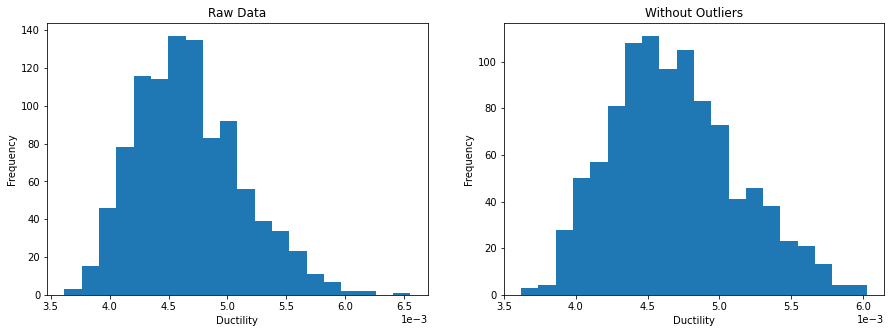

In [5]:
def plot_frequencies(duct_r, duct):
    fig1, (ax1, ax2) = plt.subplots(1, 2)
    fig1.set_figheight(5)
    fig1.set_figwidth(15)
    
    ax1.set_title('Raw Data')
    ax1.hist(duct_r, bins=20)
    ax1.set_ylabel('Frequency')
    ax1.set_xlabel('Ductility')
    ax1.ticklabel_format(axis='x', style='sci', scilimits=(0,1))
    
    ax2.set_title('Without Outliers')
    ax2.hist(duct, bins=20)
    ax2.set_ylabel('Frequency')
    ax2.set_xlabel('Ductility')
    ax2.ticklabel_format(axis='x', style='sci', scilimits=(0,1))
    
    plt.show()
    
plot_frequencies(duct_r, duct)

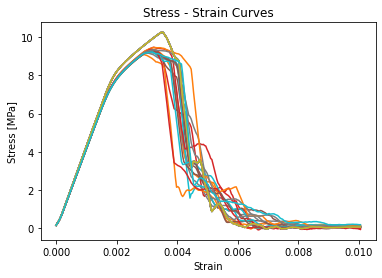

In [6]:
def plot_curve(OUT_df, xOUT, q=15):
    idxs = list(set([random.randint(0, len(OUT_df)) for i in range(q)]))
    
    fig2, ax1 = plt.subplots()
    for idx in idxs:
        ax1.set_title("Stress - Strain Curves")
        ax1.plot(xOUT, OUT_df.iloc[0].tolist())
        ax1.plot(xOUT, OUT_df.iloc[idx].tolist())
        ax1.set_ylabel('Stress [MPa]')
        ax1.set_xlabel('Strain')
    
    plt.show()

plot_curve(OUT_df, xOUT, q=15)

Full F-d curve
R-curve

ductile disStruts 12X16 thickness = 0.4 ???